# Object Detection using YOLOv8 and OpenCV

This project detects objects in images using **YOLOv8** and **OpenCV**.

### Features
- Loads YOLOv8 Nano model
- Detects multiple objects
- Draws bounding boxes and labels
- Counts detected objects
- Displays the result


In [1]:
# Install required libraries
!pip install -q ultralytics opencv-python matplotlib

In [2]:
# Import libraries
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load YOLOv8 Nano model
model = YOLO("yolov8n.pt")

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [3]:
# Download a sample image
import urllib.request

image_url = "https://ultralytics.com/images/bus.jpg"
image_path = "bus.jpg"

urllib.request.urlretrieve(image_url, image_path)

print("Sample image downloaded successfully.")

Sample image downloaded successfully.


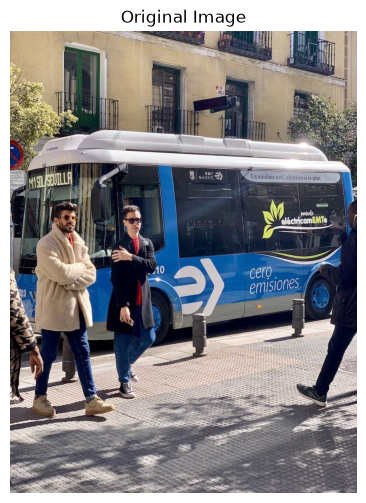

In [4]:
# Read the image
image = cv2.imread(image_path)

# Convert BGR to RGB for displaying with Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [5]:
# Run object detection
results = model(image, verbose=False)

# Draw detections on the image
detected_image = results[0].plot()

# Count detected objects
object_count = len(results[0].boxes)

print("Total objects detected:", object_count)

Total objects detected: 6


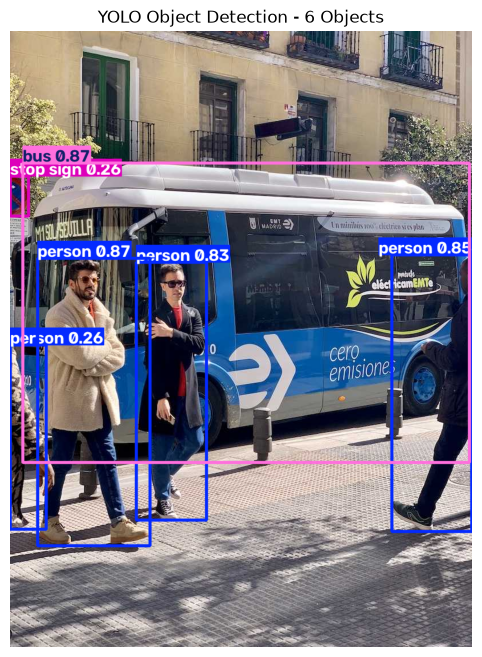

In [6]:
# Display detected objects
detected_rgb = cv2.cvtColor(detected_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(detected_rgb)
plt.axis("off")
plt.title(f"YOLO Object Detection - {object_count} Objects")
plt.show()

In [7]:
# Display object names and confidence scores
names = model.names

print("Detected objects:")
for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    print(f"- {names[class_id]} : {confidence:.2%}")

Detected objects:
- bus : 87.34%
- person : 86.57%
- person : 85.28%
- person : 82.52%
- person : 26.11%
- stop sign : 25.51%


In [8]:
# Count each type of detected object
from collections import Counter

object_names = []

for box in results[0].boxes:
    class_id = int(box.cls[0])
    object_names.append(names[class_id])

counts = Counter(object_names)

print("Object Count:")
for obj, count in counts.items():
    print(f"{obj}: {count}")

Object Count:
bus: 1
person: 4
stop sign: 1


In [9]:
# Save the final detected image
output_path = "object_detection_result.jpg"
cv2.imwrite(output_path, detected_image)

print(f"Result saved as: {output_path}")

Result saved as: object_detection_result.jpg


## Conclusion

The project successfully uses **YOLOv8 and OpenCV** to detect objects from an image. It identifies objects, draws bounding boxes, shows confidence scores, counts the detected objects, and saves the final output image.